In [1]:
import pandas as pd
from SynOmics.metrics.narrow_utility.BayesianComparison import BayesianComparison

seeds = [42,0,1,2,3]
cancers = ["ccRCC", "Melanoma","NSCLC"]
algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop"]
Cancer_dict = {}
for cancer in cancers:
    if cancer == 'ccRCC':
        score = pd.read_csv(f"../ccRCC/NarrowUtility/CellDecovo/AitchisonDistance/Score.csv", index_col = 0).T.to_dict(orient='list')
        # algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop","TVAE"]
    if cancer == 'Melanoma':
        score = pd.read_csv(f"../Melanoma/NarrowUtility/CellDecovo/AitchisonDistance/Score.csv",index_col = 0).T.to_dict(orient='list')
        # algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", 'TVAE']
    if cancer == 'NSCLC':
        score = pd.read_csv(f"../NSCLC/NarrowUtility/CellDeco/AitchisonDistance/Score.csv",index_col = 0).T.to_dict(orient='list')
    # df_cancer = pd.DataFrame(score_dict, index = algo).T
    Cancer_dict[cancer] = score

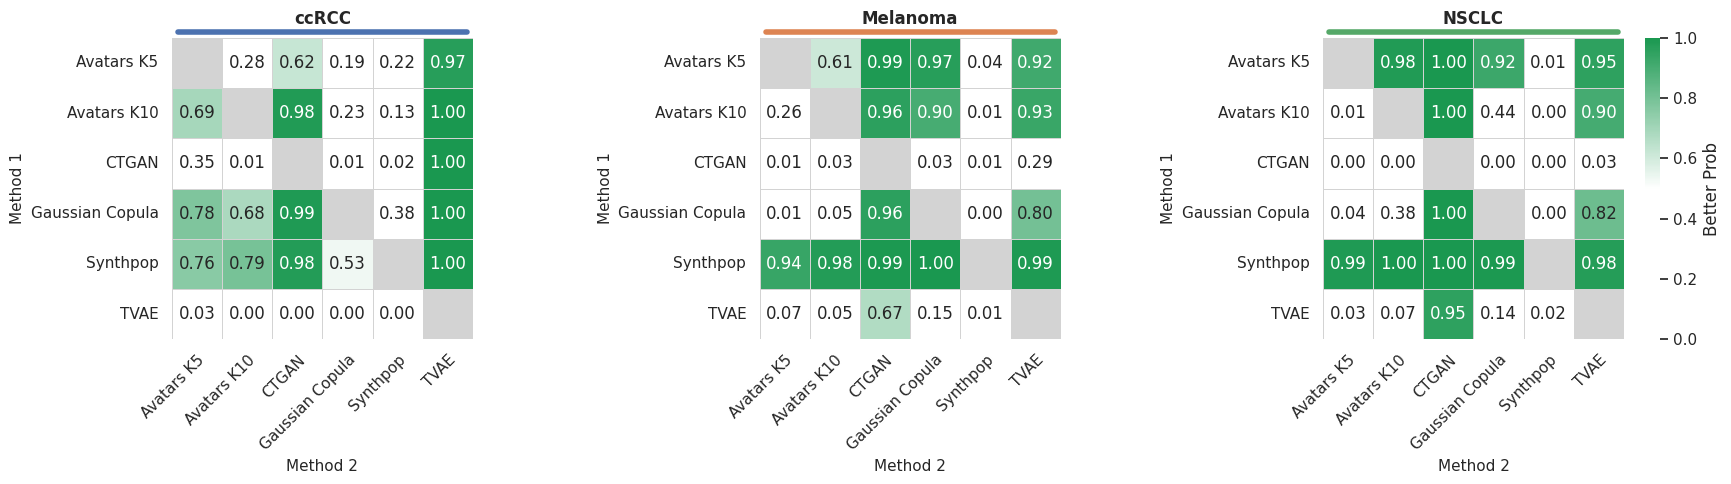

In [3]:
bc = BayesianComparison(rope=0.01)
methods_order = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
fig, axes, mats_by_cancer, comp_by_cancer = bc.plot_pbetter_heatmap_grid(
    cancer_to_method_scores=Cancer_dict,
    cancers_order=["ccRCC", "Melanoma", "NSCLC"],
    methods_order=methods_order,
    value_col="Better Prob", 
    figsize=(18, 5),
    annot=True,
    fmt=".2f",
)

fig.savefig("AitchisonDistance_Bayesian.png", bbox_inches="tight", facecolor="white")
for cancer in cancers:
    bayesian_comp_df = comp_by_cancer[cancer]
    bayesian_comp_df.to_csv(f'AitchisonDistance_Bayesian_{cancer}.csv')